In [1]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.wrappers.scikit_learn import KerasClassifier
import keras_tuner as kt
import keras
from sklearn import metrics
from sklearn import model_selection
from tensorflow import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve


In [13]:
# import platform 
# version = platform.python_version()
# print(f'Your version: {version}')

Your version: 3.10.9


In [5]:
mat = scipy.io.loadmat('trainingValidationTestingSet.mat')

#XTestDifferentVersions - to 2o arxeio

In [6]:
XTrain = mat['XTrain']
XTest = mat['XTest']
XVal = mat['XVal']
yTrain = mat['YTrain']
yTest = mat['YTest']
yVal = mat['YVal']

In [7]:
# ---------------------------------------New model---------------------------------------
def model_builder(hp):
    # create model object
    model_cnn = keras.Sequential([
    #adding first convolutional layer    
        
    keras.layers.Conv2D(
        #adding filter 
        filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=16),
        # adding filter size or kernel size
        kernel_size=hp.Choice('conv_1_kernel', values = [3,5]),
        #activation function
        activation='relu',
        input_shape=(129,14,4)),
    
    keras.layers.MaxPool2D(pool_size=(2,2)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.25),
        
    keras.layers.Conv2D(
        #adding filter 
        filters=hp.Int('conv_2_filter', min_value=32, max_value=128, step=16),
        #adding filter size or kernel size
        kernel_size=hp.Choice('conv_2_kernel', values = [3,5]),
        #activation function
        activation='relu'
    ),
        
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.25),

    # adding flatten layer    
    keras.layers.Flatten(),
    # adding dense layer    
    keras.layers.Dense(
        units=hp.Int('dense_1_units', min_value=32, max_value=128, step=16),
        activation='relu'
    ),
    
    tf.keras.layers.BatchNormalization() ,
    tf.keras.layers.Dropout(rate=0.25),
        
    # output layer    
    keras.layers.Dense(2, activation='softmax')
    ])
    
    
    #compilation of model
    model_cnn.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3])),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return model_cnn

In [11]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', mode = 'auto', patience = 3)
# This callback will stop the training when there is no improvement in
# the loss for three consecutive epochs.

In [13]:
tuner = kt.Hyperband (model_builder, 
                     objective='val_loss',
                     max_epochs=15,
                     factor=3,
                     directory='project__',
                     project_name='Name',
                     overwrite = True)

In [14]:
tuner.search (XTrain, yTrain, epochs=50 , validation_data= (XVal, yVal) , callbacks=[stop_early])

Trial 30 Complete [00h 06m 57s]
val_loss: 0.4210142493247986

Best val_loss So Far: 0.41242384910583496
Total elapsed time: 01h 45m 32s
INFO:tensorflow:Oracle triggered exit


In [43]:
#New 
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

fil1 = best_hps.Int('conv_1_filter', 3,5)
ker1 = best_hps.Int('conv_1_kernel', 3,5)
fil2 = best_hps.Int('conv_2_filter', 3,5)
ker2 = best_hps.Int('conv_2_kernel', 3,5)
lr   = best_hps.Float('learning_rate', 0.001, 0.01)
unts = best_hps.Int('dense_1_units',32,128)

[fil1,ker1,fil2,ker2,lr,unts]   


[80, 5, 80, 5, 0.001, 128]

In [122]:
model_best = tuner.hypermodel.build(best_hps)

In [127]:
#history = model_best.fit(XTrain, yTrain, epochs=50 , validation_data= (XVal, yVal) , callbacks=[stop_early])

In [128]:
# plt.plot(history.history['accuracy'], label='accuracy')
# plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.ylim([0.1, 1])
# plt.legend(loc='lower right')

In [223]:
#model_best.save('CNN_Best_Binary_Hyper_TestAcc88_2')
from keras.models import load_model
model_best = load_model('CNN_Best_Binary_Hyper_TestAcc88_2')

In [224]:
eval_result = model_best.evaluate(XTest, yTest)
accuracy = eval_result[1]
print("[test loss, test accuracy]:", eval_result)

215/215 [==============================] - 7s 29ms/step - loss: 0.3317 - accuracy: 0.8821
[test loss, test accuracy]: [0.3316841721534729, 0.8821126222610474]


In [225]:
test_loss = eval_result[0]
test_accuracy = eval_result[1]

In [226]:
a = [test_loss, test_accuracy]
df = pd.DataFrame(a, columns=['Evaluation of the model'], index=['test_loss', 'test accuracy'])
df

,Evaluation of the model
test_loss,0.331684
test accuracy,0.882113


[Text(0, 0, '0.331684'), Text(0, 0, '0.882113')]

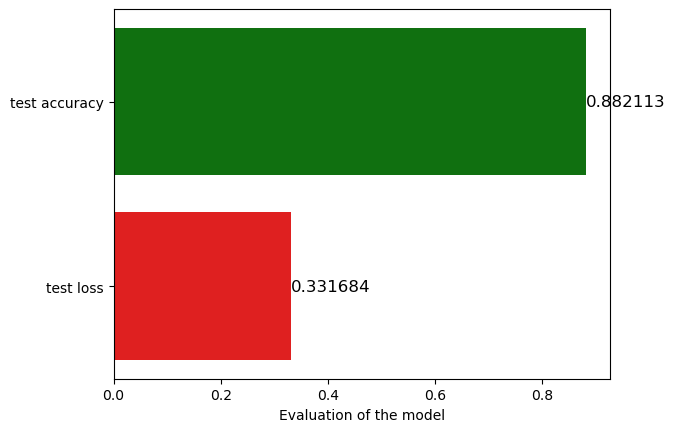

In [261]:
cols = ['red', 'green']
fig, ax = plt.subplots()
ax = sns.barplot(x='Evaluation of the model', y= ['test loss', 'test accuracy'], data= df,capsize=0.5, palette=cols)

#hbars = ax.barh(y_pos, performance, xerr=error, align='center')
#ax.set_yticks(y_pos, labels=people)
ax.invert_yaxis()  # labels read top-to-bottom
#ax.set_xlabel('')
ax.set_title('')
ax.bar_label(ax.containers[0], fontsize= 12)


In [262]:
yTestFlatten = yTest.flatten()                                             # Transpose the yTest to 1-D array
predictions_test = model_best.predict(XTest)
y_pred = np.argmax(predictions_test, axis=1)

acc_test = np.mean(y_pred == yTestFlatten)
acc_test

215/215 [==============================] - 7s 30ms/step


0.882112634957689

In [263]:
predictions_test

array([[0.99686927, 0.00313073],
       [0.99738103, 0.00261889],
       [0.82421273, 0.17578727],
       ...,
       [0.55244905, 0.44755098],
       [0.05293051, 0.94706947],
       [0.01807424, 0.9819257 ]], dtype=float32)

In [264]:
yTest

array([[0],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]], dtype=uint8)

In [265]:
conf_mat = confusion_matrix(yTestFlatten, y_pred)

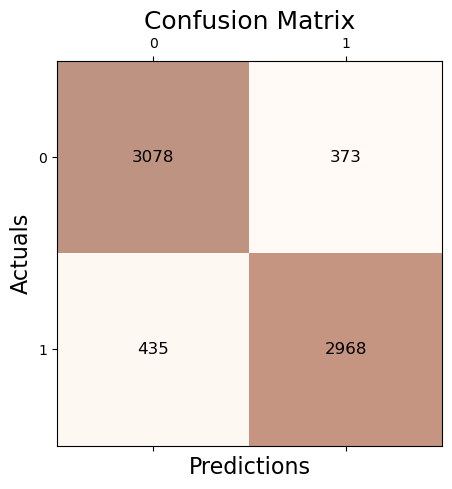

In [266]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_mat, cmap=plt.cm.Oranges, alpha=0.5)
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        ax.text(x=j, y=i,s=conf_mat[i, j], va='center', ha='center', size='large')
 
plt.xlabel('Predictions', fontsize=16)
plt.ylabel('Actuals', fontsize= 16)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [267]:
target_names = ['class 0', 'class 1']
print(classification_report(yTest, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.88      0.89      0.88      3451
     class 1       0.89      0.87      0.88      3403

    accuracy                           0.88      6854
   macro avg       0.88      0.88      0.88      6854
weighted avg       0.88      0.88      0.88      6854



In [269]:
report = classification_report(yTest, y_pred,output_dict=True )
report

{'0': {'precision': 0.8761742100768574,
  'recall': 0.891915386844393,
  'f1-score': 0.8839747271682941,
  'support': 3451},
 '1': {'precision': 0.888356779407363,
  'recall': 0.8721716132823979,
  'f1-score': 0.8801897983392645,
  'support': 3403},
 'accuracy': 0.882112634957689,
 'macro avg': {'precision': 0.8822654947421102,
  'recall': 0.8820435000633955,
  'f1-score': 0.8820822627537792,
  'support': 6854},
 'weighted avg': {'precision': 0.8822228361976204,
  'recall': 0.882112634957689,
  'f1-score': 0.8820955160791216,
  'support': 6854}}

In [270]:
precision = report['macro avg']['precision'] 
precision

0.8822654947421102

In [271]:
recall = report['macro avg']['recall'] 
recall

0.8820435000633955

In [272]:
f1_score = report['macro avg']['f1-score']
f1_score

0.8820822627537792

In [273]:
accuracy = eval_result[1]
accuracy

0.8821126222610474

In [274]:
yTestFlatten = yTest.flatten()                                             # Transpose the yTest to 1-D array
predictions_test = model_best.predict(XTest)
y_pred = np.argmax(predictions_test, axis=1)
y_prob = np.max(predictions_test, axis=1)

acc_test = np.mean(y_pred == yTestFlatten)
acc_test

215/215 [==============================] - 7s 30ms/step


0.882112634957689

In [275]:
def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')

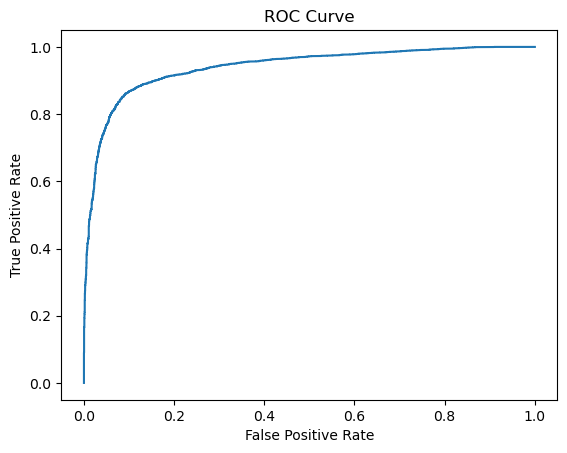

In [276]:
#plot_roc_curve(y, y_proba)
plot_roc_curve(yTest, predictions_test[:,1])

In [277]:
print(f'model AUC score: {roc_auc_score(yTest, predictions_test[:,1])}')

model AUC score: 0.9393906275106434


## Evaluation of the most useful frequency components and channels

### Checking the information given from every one of the four frequency bands

In [48]:
mat = scipy.io.loadmat('XTestDifferentVersions')

In [243]:
XTestComp1 = mat['XTestComp1']
XTestComp2 = mat['XTestComp2']
XTestComp3 = mat['XTestComp3']
XTestComp4 = mat['XTestComp4']

In [244]:
test_loss1, test_acc1 = model_best.evaluate(XTestComp1, yTest)
print("The accuracy of the model is:")
print(test_acc1)

215/215 [==============================] - 7s 30ms/step - loss: 0.6149 - accuracy: 0.7100
The accuracy of the model is:
0.7099503874778748


In [245]:
test_loss2, test_acc2 = model_best.evaluate(XTestComp2, yTest)
print("The accuracy of the model is:")
print(test_acc2)

215/215 [==============================] - 7s 31ms/step - loss: 0.6773 - accuracy: 0.7153
The accuracy of the model is:
0.7153487205505371


In [246]:
test_loss3, test_acc3 = model_best.evaluate(XTestComp3, yTest)
print("The accuracy of the model is:")
print(test_acc3)

215/215 [==============================] - 7s 33ms/step - loss: 0.3353 - accuracy: 0.8758
The accuracy of the model is:
0.8758389353752136


In [247]:
test_loss4, test_acc4 = model_best.evaluate(XTestComp4, yTest)
print("The accuracy of the model is:")
print(test_acc4)

215/215 [==============================] - 8s 39ms/step - loss: 0.3411 - accuracy: 0.8782
The accuracy of the model is:
0.8781733512878418


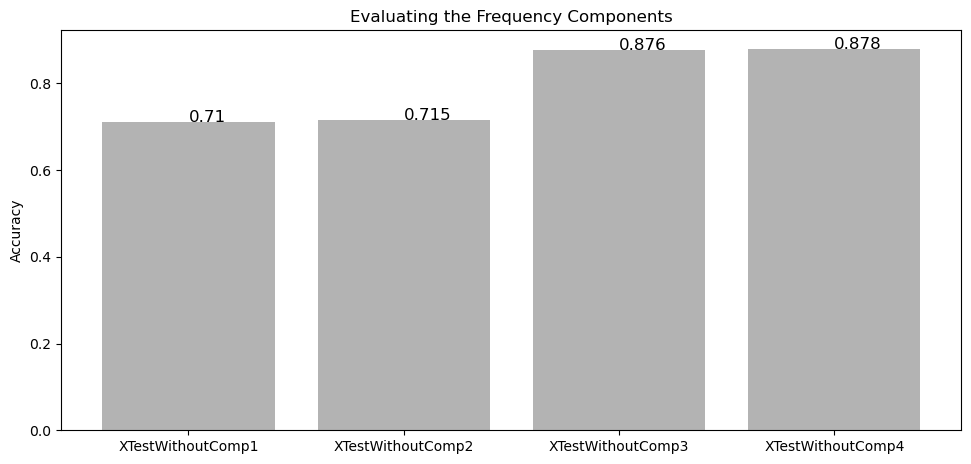

In [248]:
test_accuracies = [test_acc1, test_acc2, test_acc3 , test_acc4]

fig = plt.figure()
fig.set_figwidth(9)
fig.set_figheight(4)
ax = fig.add_axes([0,0,1,1])
x = ['XTestWithoutComp1', 'XTestWithoutComp2', 'XTestWithoutComp3', 'XTestWithoutComp4']


ax.bar(x,test_accuracies, color='0.7')
ax.set_title('Evaluating the Frequency Components')
ax.set_ylabel('Accuracy')

for index in range(len(test_accuracies)):
  ax.text(x[index], test_accuracies[index], round(test_accuracies[index], 3), size=12)

plt.show()


In [162]:
XTestOnlyComp1 = mat['XTestOnlyComp1']
XTestOnlyComp2 = mat['XTestOnlyComp2']
XTestOnlyComp3 = mat['XTestOnlyComp3']
XTestOnlyComp4 = mat['XTestOnlyComp4']

In [282]:
test_loss, test_acc5 = model_best.evaluate(XTestOnlyComp1, yTest)
print("The accuracy of the model is:")
print(test_acc5)


y_pred = model_best.predict(XTestOnlyComp1)
y_pred = np.argmax(y_pred, axis=1)

conf_mat = confusion_matrix(yTest, y_pred)

215/215 [==============================] - 7s 30ms/step - loss: 0.7198 - accuracy: 0.6952
The accuracy of the model is:
0.6952144503593445
215/215 [==============================] - 7s 33ms/step


In [164]:
# fig, ax = plt.subplots(figsize=(5, 5))
# ax.matshow(conf_mat, cmap=plt.cm.Oranges, alpha=0.3)
# for i in range(conf_mat.shape[0]):
#     for j in range(conf_mat.shape[1]):
#         ax.text(x=j, y=i,s=conf_mat[i, j], va='center', ha='center', size='xx-large')
 
# plt.xlabel('Predictions', fontsize=18)
# plt.ylabel('Actuals', fontsize=18)
# plt.title('Confusion Matrix', fontsize=18)
# plt.show()

In [278]:
test_loss, test_acc6 = model_best.evaluate(XTestOnlyComp2, yTest)
print("The accuracy of the model is:")
print(test_acc6)

215/215 [==============================] - 7s 33ms/step - loss: 0.8262 - accuracy: 0.5158
The accuracy of the model is:
0.5157572031021118


In [283]:
test_loss, test_acc7 = model_best.evaluate(XTestOnlyComp3, yTest)
print("The accuracy of the model is:")
print(test_acc7)

215/215 [==============================] - 7s 31ms/step - loss: 1.1501 - accuracy: 0.3226
The accuracy of the model is:
0.3225853443145752


In [284]:
test_loss, test_acc8 = model_best.evaluate(XTestOnlyComp4, yTest)
print("The accuracy of the model is:")
print(test_acc8)

215/215 [==============================] - 8s 38ms/step - loss: 1.0215 - accuracy: 0.3715
The accuracy of the model is:
0.3714619278907776


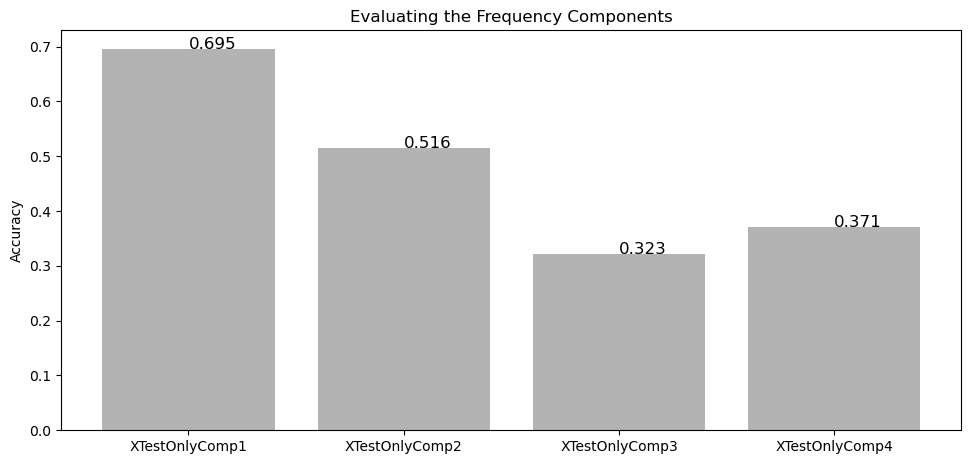

In [285]:
test_accuracies = [test_acc5, test_acc6, test_acc7 , test_acc8]

fig = plt.figure()
fig.set_figwidth(9)
fig.set_figheight(4)
ax = fig.add_axes([0,0,1,1])
x = ['XTestOnlyComp1', 'XTestOnlyComp2', 'XTestOnlyComp3', 'XTestOnlyComp4']


ax.bar(x,test_accuracies, color='0.7')
ax.set_title('Evaluating the Frequency Components')
ax.set_ylabel('Accuracy')

for index in range(len(test_accuracies)):
  ax.text(x[index], test_accuracies[index], round(test_accuracies[index], 3), size=12)

plt.show()


### Checking the information given from the left and the right ear

In [286]:
XTestLeftEar  = mat['XTestLeftEar']
XTestRightEar = mat['XTestRightEar']

In [287]:
test_loss, test_acc9 = model_best.evaluate(XTestLeftEar, yTest)
print("The accuracy of the model is:")
print(test_acc9)

215/215 [==============================] - 9s 44ms/step - loss: 0.5420 - accuracy: 0.7639
The accuracy of the model is:
0.7639334797859192


In [288]:
test_loss, test_acc10 = model_best.evaluate(XTestRightEar, yTest)
print("The accuracy of the model is:")
print(test_acc10)

215/215 [==============================] - 7s 33ms/step - loss: 0.2698 - accuracy: 0.8912
The accuracy of the model is:
0.8911584615707397


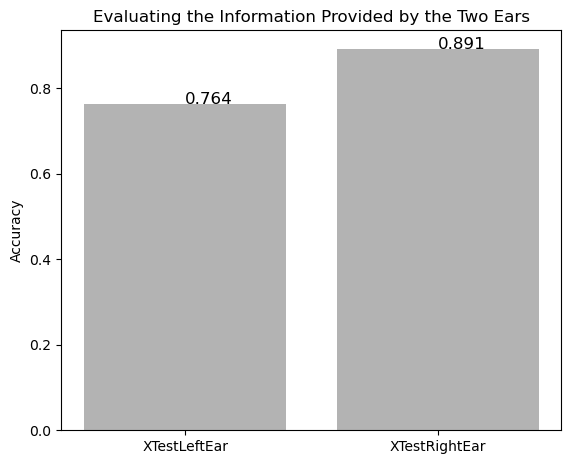

In [289]:
test_accuracies = [test_acc9, test_acc10]

fig = plt.figure()
fig.set_figwidth(5)
fig.set_figheight(4)
ax = fig.add_axes([0,0,1,1])
x = ['XTestLeftEar', 'XTestRightEar']


ax.bar(x,test_accuracies, color='0.7')
ax.set_title('Evaluating the Information Provided by the Two Ears')
ax.set_ylabel('Accuracy')

for index in range(len(test_accuracies)):
  ax.text(x[index], test_accuracies[index], round(test_accuracies[index], 3), size=12)

plt.show()


### Checking the information given from the front and the bottom side of the ears

In [82]:
XTestFrontSideOfEars  = mat['XTestFrontSideOfEars']
XTestBottomSideOfEars = mat['XTestBottomSideOfEars']

In [290]:
test_loss, test_acc11 = model_best.evaluate(XTestFrontSideOfEars, yTest)
print("The accuracy of the model is:")
print(test_acc11)

215/215 [==============================] - 7s 30ms/step - loss: 1.8986 - accuracy: 0.5193
The accuracy of the model is:
0.5192587971687317


In [175]:
test_loss, test_acc12 = model_best.evaluate(XTestBottomSideOfEars, yTest)
print("The accuracy of the model is:")
print(test_acc12)

215/215 [==============================] - 5s 22ms/step - loss: 1.1236 - accuracy: 0.6293
The accuracy of the model is:
0.6292675733566284


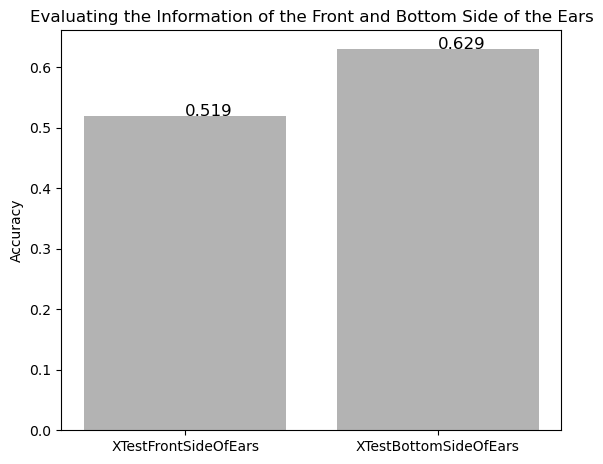

In [176]:
test_accuracies = [test_acc11, test_acc12]

fig = plt.figure()
fig.set_figwidth(5)
fig.set_figheight(4)
ax = fig.add_axes([0,0,1,1])
x = ['XTestFrontSideOfEars', 'XTestBottomSideOfEars']


ax.bar(x,test_accuracies, color='0.7')
ax.set_title('Evaluating the Information of the Front and Bottom Side of the Ears')
ax.set_ylabel('Accuracy')

for index in range(len(test_accuracies)):
  ax.text(x[index], test_accuracies[index], round(test_accuracies[index], 3), size=12)

plt.show()


In [339]:
mat = scipy.io.loadmat('XTestBottomRightThreeBands')
XTestBottomRightThreeBands = mat['XTestBottomRightThreeBands']

In [340]:
test_loss, acc_ = model_best.evaluate(XTestBottomRightThreeBands, yTest)


215/215 [==============================] - 5s 24ms/step - loss: 1.1236 - accuracy: 0.6293


In [341]:
test_loss, acc_ = model_best.evaluate(XTestBottomRightThreeBands, yTest)

215/215 [==============================] - 5s 25ms/step - loss: 1.1236 - accuracy: 0.6293


In [342]:
test_loss, acc_ = model_best.evaluate(XTestBottomRightThreeBands, yTest)
print("The accuracy of the model is:")
print(acc_)


y_pred = model_best.predict(XTestBottomRightThreeBands)
y_pred = np.argmax(y_pred, axis=1)

conf_mat = confusion_matrix(yTest, y_pred)

215/215 [==============================] - 5s 23ms/step - loss: 1.1236 - accuracy: 0.6293
The accuracy of the model is:
0.6292675733566284
215/215 [==============================] - 5s 22ms/step


## Confidence intervals for the accuracy of the test set

In [177]:
accuracy

0.8821126222610474

### Method 1: Normal Approximation Interval Based on a Test Set 

In [291]:
import scipy.stats

confidence = 0.95                                        # Define your desired confidence level
z_value = scipy.stats.norm.ppf((1 + confidence) / 2.0)    
print(z_value)          

1.959963984540054


In [292]:
yTest.size

6854

In [293]:
ci_length = z_value * np.sqrt((accuracy * (1 - accuracy)) / yTest.size)

ci_lower = accuracy - ci_length
ci_upper = accuracy + ci_length

print(ci_lower, ci_upper)

0.8744782784757326 0.8897469660463622


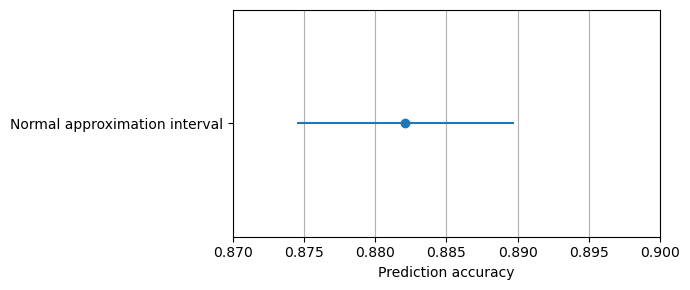

In [294]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3))

ax.errorbar(accuracy, 0, xerr=ci_length, fmt="o")

ax.set_xlim([0.87, 0.9])

ax.set_yticks(np.arange(1))
ax.set_yticklabels(["Normal approximation interval"])
ax.set_xlabel("Prediction accuracy")

plt.tight_layout()
plt.grid(axis="x")
plt.show()

In [295]:
results1 = {
    "Method 1: Normal approximation": {
        "Test accuracy": accuracy,
        "Lower 95% CI": ci_lower,
        "Upper 95% CI": ci_upper,
    }
}

In [296]:
results1

{'Method 1: Normal approximation': {'Test accuracy': 0.8821126222610474,
  'Lower 95% CI': 0.8744782784757326,
  'Upper 95% CI': 0.8897469660463622}}

### Method 2: Bootstrapping the Test Set Predictions #

In [297]:
yTestFlatten = yTest.flatten()                                             # Transpose the yTest to 1-D array
predictions_test = model_best.predict(XTest)
y_pred = np.argmax(predictions_test, axis=1)

215/215 [==============================] - 7s 31ms/step


In [298]:
acc_test = np.mean(y_pred == yTestFlatten)
acc_test

0.882112634957689

In [299]:
rng = np.random.RandomState(seed=12345)
idx = np.arange(yTestFlatten.shape[0])

test_accuracies = []

for i in range(500):
 
    pred_idx = rng.choice(idx, size=idx.shape[0], replace=True)             # Generates a random sample from a given 1-D array
    acc_test_boot = np.mean(y_pred[pred_idx] == yTestFlatten[pred_idx])  
    test_accuracies.append(acc_test_boot)

bootstrap_train_mean = np.mean(test_accuracies)
bootstrap_train_mean


0.88204931426904

In [300]:
ci_lower_2 = np.percentile(test_accuracies, 5)
ci_upper_2 = np.percentile(test_accuracies, 95)

print(ci_lower_2, ci_lower_2)

0.8750948351327692 0.8750948351327692


In [301]:
print("Test accuracy:", bootstrap_train_mean, "\n"
    "Lower 95% CI :", ci_lower_2, "\n"
    "Upper 95% CI :", ci_upper_2)

Test accuracy: 0.88204931426904 
Lower 95% CI : 0.8750948351327692 
Upper 95% CI : 0.8879559381383134


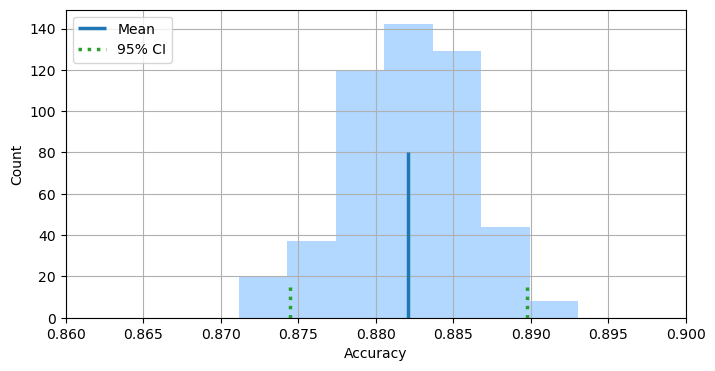

In [303]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines(bootstrap_train_mean, [0], 80, lw=2.5, linestyle="-", label="Mean")

ax.vlines(ci_lower, [0], 15, lw=2.5, linestyle="dotted", label="95% CI", color="C2")
ax.vlines(ci_upper, [0], 15, lw=2.5, linestyle="dotted", color="C2")

ax.hist(
    test_accuracies, bins=7, color="#0080ff", edgecolor="none", alpha=0.3
)
plt.legend(loc="upper left")

plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.xlim([0.86, 0.9])

plt.grid()
plt.show()

In [304]:
results1["Method 2: Bootstrapping the test set"] = {
    "Test accuracy": bootstrap_train_mean,
    "Lower 95% CI": ci_lower_2,
    "Upper 95% CI": ci_upper_2,
}

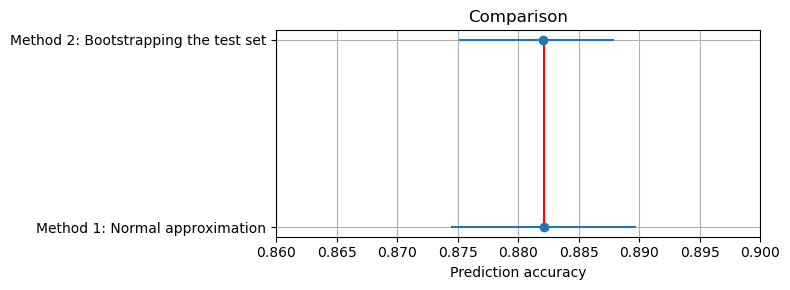

In [305]:
%matplotlib inline
import matplotlib.pyplot as plt

labels = list(results1.keys())

means = np.array([results1[k]["Test accuracy"] for k in labels])
lower_error = np.array([results1[k]["Lower 95% CI"] for k in labels])
upper_error = np.array([results1[k]["Upper 95% CI"] for k in labels])

asymmetric_error = [means - lower_error, upper_error - means]


fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(means, np.arange(len(means)), xerr=asymmetric_error, fmt="o")
ax.set_xlim([0.86, 0.9])
ax.set_yticks(np.arange(len(means)))
ax.set_yticklabels(labels)
ax.set_xlabel("Prediction accuracy")
ax.set_title("95% confidence intervals")

ax.vlines(accuracy, [0], 1, lw=1.5, color="red", linestyle="-", label="True value")

plt.title("Comparison")
plt.grid()
plt.tight_layout()
#plt.savefig("matplotlib-figures/comparison-simulation.pdf")
plt.show()

## Confidence intervals for the F1- score, precision and recall of the test set

In [306]:
f1_score

0.8820822627537792

In [307]:
precision

0.8822654947421102

In [308]:
recall

0.8820435000633955

### Method 1: Normal Approximation Interval Based on a Test Set 

In [309]:
import scipy.stats

confidence = 0.95                                        # Define your desired confidence level
z_value = scipy.stats.norm.ppf((1 + confidence) / 2.0)    
print(z_value)          

1.959963984540054


--------------------- f1_score ----------------------

In [310]:
ci_length = z_value * np.sqrt((f1_score * (1 - f1_score)) / yTest.size)

ci_lower = f1_score - ci_length
ci_upper = f1_score + ci_length

print(ci_lower, ci_upper)

0.8744470673893582 0.8897174581182002


In [311]:
results2 = {
    "Method 1: Normal approximation": {
        "Test f1-score": f1_score,
        "Lower 95% CI": ci_lower,
        "Upper 95% CI": ci_upper,
    }
}

--------------------- precision ----------------------

In [312]:
ci_length = z_value * np.sqrt((precision * (1 - precision)) / yTest.size)

ci_lower = precision - ci_length
ci_upper = precision + ci_length

print(ci_lower, ci_upper)

0.8746354414773533 0.8898955480068672


In [313]:
results3 = {
    "Method 1: Normal approximation": {
        "Test precision": precision,
        "Lower 95% CI": ci_lower,
        "Upper 95% CI": ci_upper,
    }
}

--------------------- recall ----------------------

In [314]:
ci_length = z_value * np.sqrt((recall * (1 - recall)) / yTest.size)

ci_lower = recall - ci_length
ci_upper = recall + ci_length

print(ci_lower, ci_upper)

0.8744072176483446 0.8896797824784464


In [315]:
results4 = {
    "Method 1: Normal approximation": {
        "Test recall": recall,
        "Lower 95% CI": ci_lower,
        "Upper 95% CI": ci_upper,
    }
}

### Method 2: Bootstrapping the Test Set Predictions #

In [316]:
rng = np.random.RandomState(seed=12345)
idx = np.arange(yTestFlatten.shape[0])

test_F1_score = []
test_precision = []
test_recall = []

for i in range(500):
 
    pred_idx = rng.choice(idx, size=idx.shape[0], replace=True)             # Generates a random sample from a given 1-D array
    
    report = classification_report(yTest[pred_idx], y_pred[pred_idx] ,output_dict=True )
    test_F1_score.append(report['macro avg']['f1-score'])
    test_precision.append(report['macro avg']['precision'])
    test_recall.append(report['macro avg']['recall'])

bootstrap_test_mean1 = np.mean(test_F1_score)
bootstrap_test_mean2 = np.mean(test_precision)
bootstrap_test_mean3 = np.mean(test_recall)

In [317]:
ci_lower_2 = np.percentile(test_F1_score, 5)
ci_upper_2 = np.percentile(test_F1_score, 95)

print(ci_lower_2, ci_upper_2)

0.8750140302319984 0.8879536854596957


In [318]:
ci_lower_3 = np.percentile(test_precision, 5)
ci_upper_3 = np.percentile(test_precision, 95)

print(ci_lower_3, ci_upper_3)

0.8751561589907901 0.8882020660318493


In [319]:
ci_lower_4 = np.percentile(test_recall, 5)
ci_upper_4 = np.percentile(recall, 95)

print(ci_lower_4, ci_upper_4)

0.874960538379579 0.8820435000633955


In [320]:
results2["Method 2: Bootstrapping the test set"] = {
    "Test f1-score": bootstrap_test_mean1,
    "Lower 95% CI": ci_lower_2,
    "Upper 95% CI": ci_upper_2,
}

In [321]:
results3["Method 2: Bootstrapping the test set"] = {
    "Test precision": bootstrap_test_mean2,
    "Lower 95% CI": ci_lower_2,
    "Upper 95% CI": ci_upper_2,
}

In [322]:
results4["Method 2: Bootstrapping the test set"] = {
    "Test recall": bootstrap_test_mean3,
    "Lower 95% CI": ci_lower_3,
    "Upper 95% CI": ci_upper_3,
}

--------------------- f1_score ----------------------

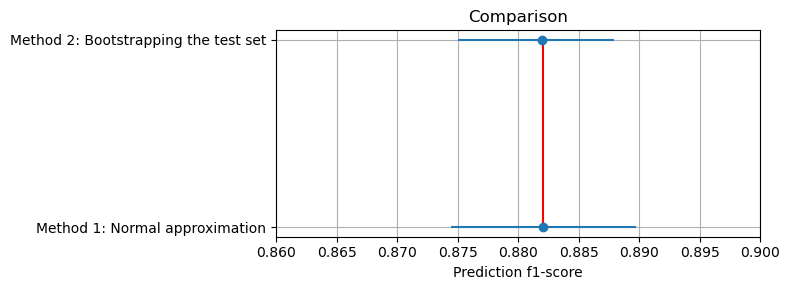

In [323]:
labels = list(results2.keys())

means = np.array([results2[k]["Test f1-score"] for k in labels])
lower_error = np.array([results2[k]["Lower 95% CI"] for k in labels])
upper_error = np.array([results2[k]["Upper 95% CI"] for k in labels])

asymmetric_error = [means - lower_error, upper_error - means]


fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(means, np.arange(len(means)), xerr=asymmetric_error, fmt="o")
ax.set_xlim([0.86, 0.9])
ax.set_yticks(np.arange(len(means)))
ax.set_yticklabels(labels)
ax.set_xlabel("Prediction f1-score")
ax.set_title("95% confidence intervals")

ax.vlines(f1_score, [0], 1, lw=1.5, color="red", linestyle="-", label="True value")

plt.title("Comparison")
plt.grid()
plt.tight_layout()
plt.show()

--------------------- precision ----------------------

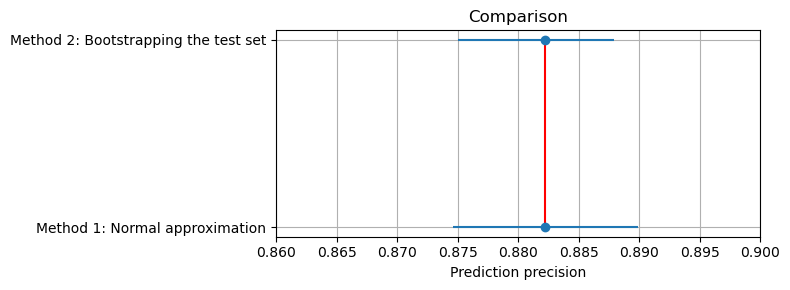

In [331]:
labels = list(results3.keys())

means = np.array([results3[k]["Test precision"] for k in labels])
lower_error = np.array([results3[k]["Lower 95% CI"] for k in labels])
upper_error = np.array([results3[k]["Upper 95% CI"] for k in labels])

asymmetric_error = [means - lower_error, upper_error - means]


fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(means, np.arange(len(means)), xerr=asymmetric_error, fmt="o")
ax.set_xlim([0.86, 0.9])
ax.set_yticks(np.arange(len(means)))
ax.set_yticklabels(labels)
ax.set_xlabel("Prediction precision")
ax.set_title("95% confidence intervals")

ax.vlines(precision, [0], 1, lw=1.5, color="red", linestyle="-", label="True value")

plt.title("Comparison")
plt.grid()
plt.tight_layout()
plt.show()

--------------------- recall ----------------------

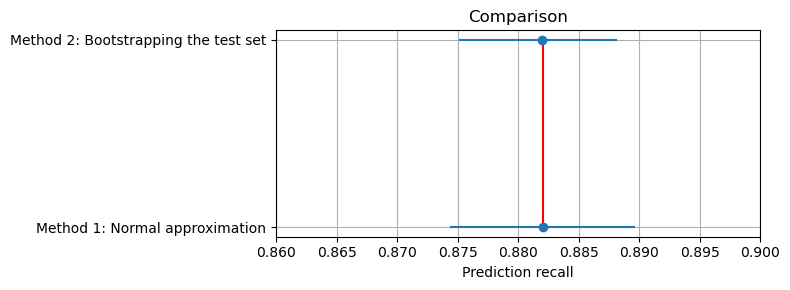

In [333]:
labels = list(results4.keys())

means = np.array([results4[k]["Test recall"] for k in labels])
lower_error = np.array([results4[k]["Lower 95% CI"] for k in labels])
upper_error = np.array([results4[k]["Upper 95% CI"] for k in labels])

asymmetric_error = [means - lower_error, upper_error - means]


fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(means, np.arange(len(means)), xerr=asymmetric_error, fmt="o")
ax.set_xlim([0.86, 0.9])
ax.set_yticks(np.arange(len(means)))
ax.set_yticklabels(labels)
ax.set_xlabel("Prediction recall")
ax.set_title("95% confidence intervals")

ax.vlines(recall, [0], 1, lw=1.5, color="red", linestyle="-", label="True value")

plt.title("Comparison")
plt.grid()
plt.tight_layout()
plt.show()

In [334]:
results1                          #accuracy

{'Method 1: Normal approximation': {'Test accuracy': 0.8821126222610474,
  'Lower 95% CI': 0.8744782784757326,
  'Upper 95% CI': 0.8897469660463622},
 'Method 2: Bootstrapping the test set': {'Test accuracy': 0.88204931426904,
  'Lower 95% CI': 0.8750948351327692,
  'Upper 95% CI': 0.8879559381383134}}

In [335]:
results2                          #f1_score

{'Method 1: Normal approximation': {'Test f1-score': 0.8820822627537792,
  'Lower 95% CI': 0.8744470673893582,
  'Upper 95% CI': 0.8897174581182002},
 'Method 2: Bootstrapping the test set': {'Test f1-score': 0.8819999554928372,
  'Lower 95% CI': 0.8750140302319984,
  'Upper 95% CI': 0.8879536854596957}}

In [336]:
results3                          #precision

{'Method 1: Normal approximation': {'Test precision': 0.8822654947421102,
  'Lower 95% CI': 0.8746354414773533,
  'Upper 95% CI': 0.8898955480068672},
 'Method 2: Bootstrapping the test set': {'Test precision': 0.8822077629909527,
  'Lower 95% CI': 0.8750140302319984,
  'Upper 95% CI': 0.8879536854596957}}

In [337]:
results4                          #recall

{'Method 1: Normal approximation': {'Test recall': 0.8820435000633955,
  'Lower 95% CI': 0.8744072176483446,
  'Upper 95% CI': 0.8896797824784464},
 'Method 2: Bootstrapping the test set': {'Test recall': 0.8819727891420192,
  'Lower 95% CI': 0.8751561589907901,
  'Upper 95% CI': 0.8882020660318493}}